# Exploratory Data Analysis (EDA)

In this section, I explore the self-collected dataset of daily social media platform usage and mood scores.  
The main goal of this EDA is to understand basic patterns in:

- How much time I spend on each platform (Instagram, X/Twitter, TikTok, YouTube)
- How my daily anxiety, social comparison, productivity, and motivation scores change over time
- Whether there are visible associations between platform usage and these psychological variables

The analysis is structured into:
1. Preliminary steps (loading and inspecting the data)  
2. Summary statistics  
3. Correlation analysis  
4. Visual exploration of key relationships  
5. Initial observations and insights  

## 1. Preliminary Steps

### 1.1 Importing Libraries and Loading the Dataset

In this part, I import the main Python libraries used for data analysis and visualization,  
and load the daily social media dataset from the CSV file.

Each row in the dataset represents a single day and contains:

- Minutes spent on Instagram, X/Twitter, TikTok, and YouTube  
- Self-reported scores for anxiety, social comparison, productivity, and motivation  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("daily_social_media.csv")
df.head()


,date,ig_min,tw_min,tt_min,yt_min,anxiety,soc_comp,productivity,motivation,notes
0,2025-11-09,48,72,78,32,7,7,8,6,I had an early exam I woke up early and studie...
1,2025-11-10,81,90,85,38,8,5,4,5,After yesterday I was really tired and could n...
2,2025-11-11,42,55,70,63,6,5,9,8,I have finished exactly what I planned for tod...
3,2025-11-12,41,88,80,76,6,7,6,6,I could not do anything after my classes
4,2025-11-13,62,65,78,35,7,7,7,6,Finished more than half of my plan


## 2. Dataset Overview

In this section, I inspect the basic structure of the dataset using `.info()` and check for missing values.  
This helps confirm that all columns are correctly loaded and that there are no obvious data quality issues  
before moving on to more detailed analysis.


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          21 non-null     object
 1   ig_min        21 non-null     int64 
 2   tw_min        21 non-null     int64 
 3   tt_min        21 non-null     int64 
 4   yt_min        21 non-null     int64 
 5   anxiety       21 non-null     int64 
 6   soc_comp      21 non-null     int64 
 7   productivity  21 non-null     int64 
 8   motivation    21 non-null     int64 
 9   notes         21 non-null     object
dtypes: int64(8), object(2)
memory usage: 1.8+ KB


In [5]:
df.isna().sum()


date            0
ig_min          0
tw_min          0
tt_min          0
yt_min          0
anxiety         0
soc_comp        0
productivity    0
motivation      0
notes           0
dtype: int64

## 3. Summary Statistics

Here I compute descriptive statistics for all numerical variables using `.describe()`.  
This provides information about:

- The average time spent on each platform  
- The typical range of my anxiety, social comparison, productivity, and motivation scores  
- Whether any variables have unusually high or low values

These statistics give a first impression of how balanced or skewed my usage and mood patterns are.


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ig_min,21.0,53.761905,18.446964,15.0,42.0,55.0,68.0,81.0
tw_min,21.0,70.809524,15.357796,33.0,65.0,72.0,83.0,92.0
tt_min,21.0,84.285714,22.488092,45.0,75.0,85.0,96.0,126.0
yt_min,21.0,51.333333,19.822546,25.0,36.0,43.0,67.0,100.0
anxiety,21.0,7.000000,1.264911,5.0,6.0,7.0,8.0,10.0
soc_comp,21.0,6.857143,1.424279,4.0,6.0,7.0,8.0,9.0
productivity,21.0,6.000000,2.000000,2.0,4.0,6.0,8.0,9.0
motivation,21.0,6.190476,1.364516,3.0,5.0,6.0,7.0,8.0


## Relationships Between Platform Usage and Well-Being Variables

After examining descriptive statistics, I now explore the relationships between
daily platform usage (Instagram, Twitter/X, TikTok, YouTube) and the self-reported
well-being scores: anxiety, social comparison, productivity, and motivation.

The analysis is organized based on the main research questions (RQ1–RQ3).


### RQ1 – Platform Use and Anxiety

This section investigates how much time I spent on Instagram, Twitter/X, and TikTok
and how these usage patterns relate to my daily anxiety levels.

- **H1:** Twitter/X will show the strongest positive relationship with anxiety  
  due to exposure to negative news or stressful content.

- **H0₁:** There is no relationship between platform usage and anxiety.

Below I examine correlations and scatterplots to visually inspect these patterns.


Correlation with Anxiety:

anxiety    1.000000
tw_min     0.471012
tt_min     0.128316
ig_min    -0.008571
Name: anxiety, dtype: float64


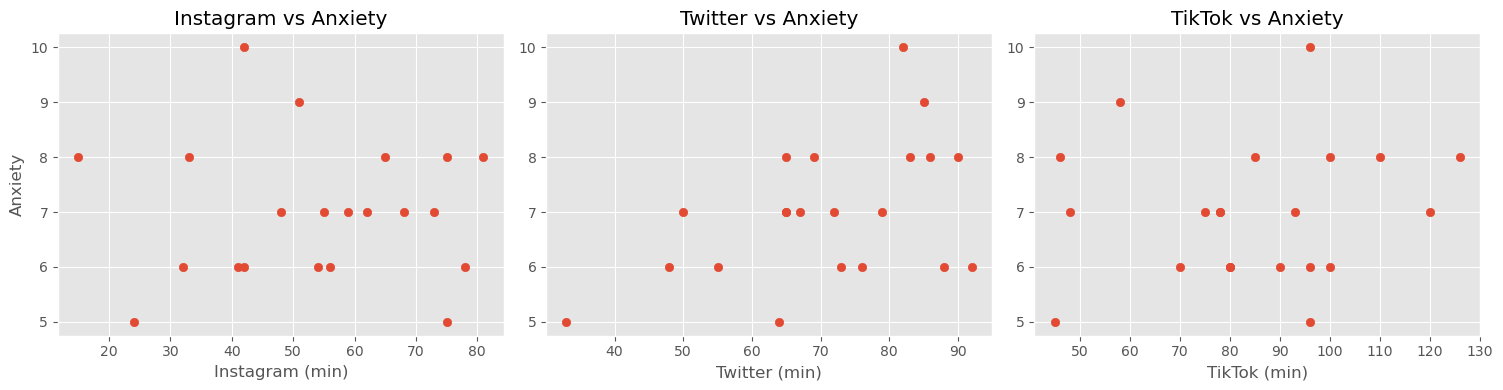

In [8]:
# Columns relevant to RQ1
rq1_cols = ["ig_min", "tw_min", "tt_min", "anxiety"]

# Correlation with anxiety
print("Correlation with Anxiety:\n")
print(df[rq1_cols].corr()["anxiety"].sort_values(ascending=False))

# Scatterplots: each platform vs anxiety
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(df["ig_min"], df["anxiety"])
plt.title("Instagram vs Anxiety")
plt.xlabel("Instagram (min)")
plt.ylabel("Anxiety")

plt.subplot(1,3,2)
plt.scatter(df["tw_min"], df["anxiety"])
plt.title("Twitter vs Anxiety")
plt.xlabel("Twitter (min)")

plt.subplot(1,3,3)
plt.scatter(df["tt_min"], df["anxiety"])
plt.title("TikTok vs Anxiety")
plt.xlabel("TikTok (min)")

plt.tight_layout()
plt.show()


### RQ2 – Platform Use and Social Comparison

Here I explore how time spent on Instagram, Twitter/X, and TikTok relates  
to daily social comparison tendencies.

- **H2:** Instagram and TikTok are expected to show the strongest associations  
  because their content is highly appearance- and lifestyle-focused.

- **H0₂:** Platform usage has no relationship with social comparison.


Correlation with Social Comparison:

soc_comp    1.000000
tw_min      0.261565
ig_min      0.204170
tt_min      0.051292
Name: soc_comp, dtype: float64


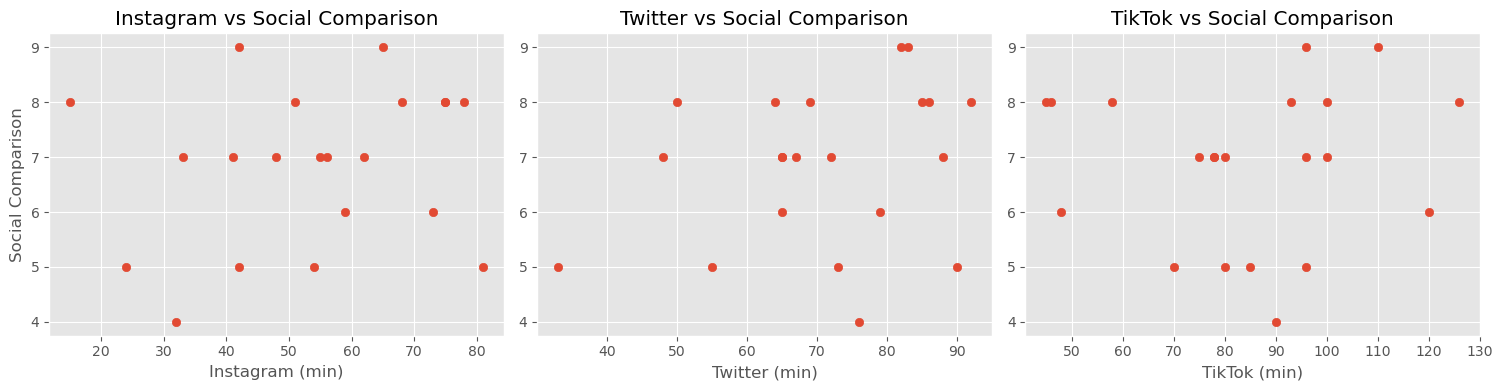

In [9]:
rq2_cols = ["ig_min", "tw_min", "tt_min", "soc_comp"]

# Correlation with social comparison
print("Correlation with Social Comparison:\n")
print(df[rq2_cols].corr()["soc_comp"].sort_values(ascending=False))

# Scatterplots
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(df["ig_min"], df["soc_comp"])
plt.title("Instagram vs Social Comparison")
plt.xlabel("Instagram (min)")
plt.ylabel("Social Comparison")

plt.subplot(1,3,2)
plt.scatter(df["tw_min"], df["soc_comp"])
plt.title("Twitter vs Social Comparison")
plt.xlabel("Twitter (min)")

plt.subplot(1,3,3)
plt.scatter(df["tt_min"], df["soc_comp"])
plt.title("TikTok vs Social Comparison")
plt.xlabel("TikTok (min)")

plt.tight_layout()
plt.show()


### RQ3 – Platform Use, Productivity and Motivation

This section examines how YouTube, TikTok, and other platforms relate to  
daily productivity and motivation.

- **H3:** YouTube may correlate positively with productivity and motivation,  
  especially when used for educational or long-form content.

- TikTok (and possibly Instagram) may correlate negatively with productivity  
  due to highly distracting short-form content.

- **H0₃:** Platform usage has no relationship with productivity or motivation.


In [11]:
rq3_cols = ["ig_min", "tw_min", "tt_min", "yt_min", "productivity", "motivation"]

print("Correlation with Productivity:\n")
print(df[rq3_cols].corr()["productivity"].sort_values(ascending=False))

print("\nCorrelation with Motivation:\n")
print(df[rq3_cols].corr()["motivation"].sort_values(ascending=False))


Correlation with Productivity:

productivity    1.000000
motivation      0.842789
yt_min          0.435111
ig_min         -0.375401
tw_min         -0.480212
tt_min         -0.579195
Name: productivity, dtype: float64

Correlation with Motivation:

motivation      1.000000
productivity    0.842789
yt_min          0.589072
ig_min         -0.286136
tw_min         -0.587513
tt_min         -0.660156
Name: motivation, dtype: float64


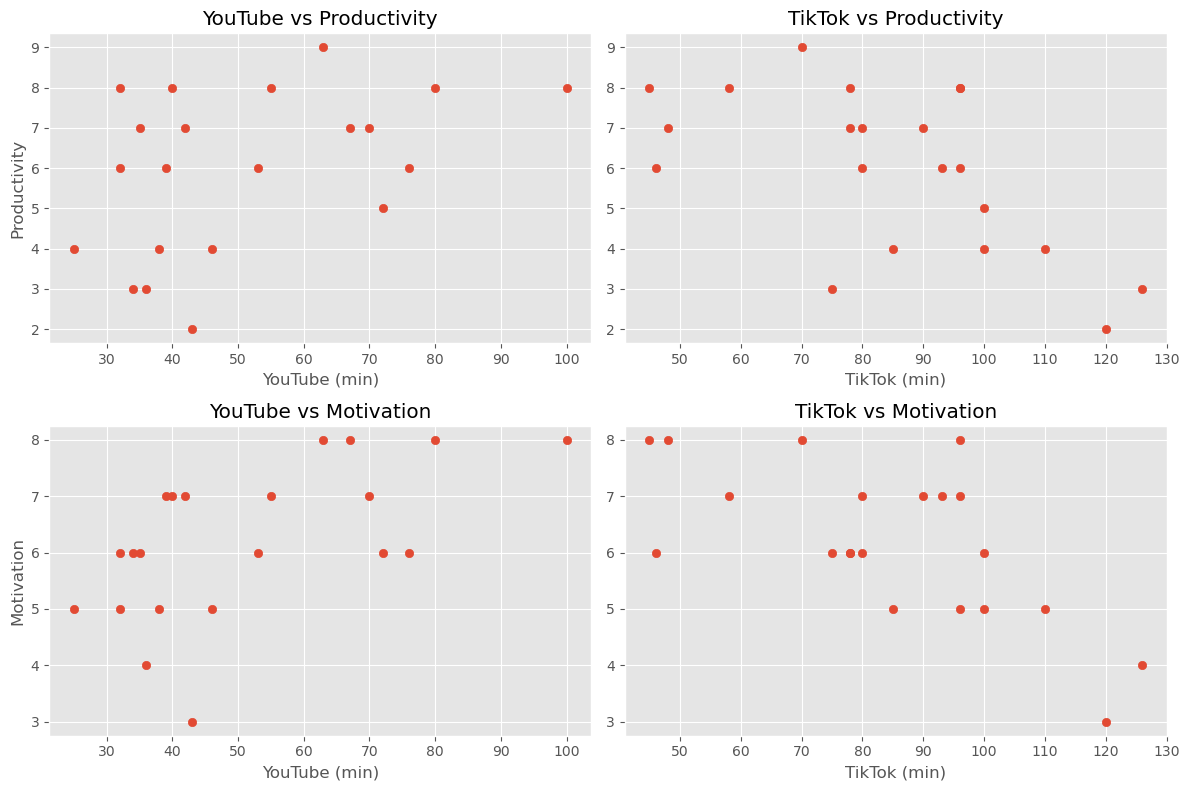

In [13]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.scatter(df["yt_min"], df["productivity"])
plt.title("YouTube vs Productivity")
plt.xlabel("YouTube (min)")
plt.ylabel("Productivity")

plt.subplot(2,2,2)
plt.scatter(df["tt_min"], df["productivity"])
plt.title("TikTok vs Productivity")
plt.xlabel("TikTok (min)")

plt.subplot(2,2,3)
plt.scatter(df["yt_min"], df["motivation"])
plt.title("YouTube vs Motivation")
plt.xlabel("YouTube (min)")
plt.ylabel("Motivation")

plt.subplot(2,2,4)
plt.scatter(df["tt_min"], df["motivation"])
plt.title("TikTok vs Motivation")
plt.xlabel("TikTok (min)")

plt.tight_layout()
plt.show()
